# 2차 모델 — 시설 + 인구 + 구조위험 통합 사고 예측 (개선 버전)

| 구분 | 원본 코드 | 개선 코드 |
|------|-----------|-----------|
| ① 피처: 어린이 총인구 | 원본값 그대로 (수천 단위) | `log1p` 변환 적용 |
| ② 피처: 상호작용 항 | 없음 | `structure_risk × 시설변수` 5개 추가 |
| ③ 과적합 | 전체 학습 후 동일 데이터 Top-20% 평가 (누수) | CV fold 내부에서만 평가 |
| ④ 소수 클래스 | `class_weight=balanced` 만 | SMOTE + `class_weight=balanced` |
| ⑤ 하이퍼파라미터 | `C=1.0` 고정 | `GridSearchCV` 자동 탐색 |
| ⑥ 확률 보정 | 없음 | `CalibratedClassifierCV` 적용 |
| ⑦ 분류 임계값 | `0.5` 고정 | PR 커브 기반 F1 최적 임계값 |
| ⑧ 안전등급 기준 | `pd.qcut` (데이터 추가 시 등급 변동) | 절대 임계값 고정 (A<20%, B<40%, C<60%, D≥60%) |


In [1]:
# ============================================================
# 라이브러리 로드
# 최초 실행 시: pip install imbalanced-learn shap
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료 ✅')


라이브러리 로드 완료 ✅


In [2]:
# ============================================================
# 데이터 로드
# 2_DatasetFor2ndData.csv 에는 structure_risk 가 이미 포함되어 있음
# (1차 모델을 별도로 실행하지 않아도 됨)
# ============================================================
facility_df = pd.read_csv("./2_DatasetFor2ndData.csv")
facility_df["accident_label"] = (facility_df["발생건수"] >= 1).astype(int)

print(f"로드 완료: {len(facility_df)}개 스쿨존")
print(f"사고: {facility_df['accident_label'].sum()}개 ({facility_df['accident_label'].mean()*100:.1f}%) | 비사고: {(facility_df['accident_label']==0).sum()}개")
facility_df[['시설물명','발생건수','accident_label','structure_risk']].head()


로드 완료: 117개 스쿨존
사고: 7개 (6.0%) | 비사고: 110개


,시설물명,발생건수,accident_label,structure_risk
0,중원초등학교,0,0,0.271869
1,하원초등학교,0,0,0.479237
2,중부초등학교,0,0,0.340592
3,상대원초등학교,0,0,0.321461
4,구미초등학교,0,0,0.446789


In [3]:
# ============================================================
# [개선 ①②] 피처 전처리 — log1p 변환 + 상호작용 항
# ============================================================
FACILITY_COLS = [
    '도로안전표지','도로적색표면','무단횡단방지펜스','무인교통단속카메라',
    '보호구역표지판','생활안전CCTV','신호등','옐로카펫','횡단보도'
]

# 왜도 확인 후 > 1.0 변수에 log1p 적용
skew_cols = FACILITY_COLS + ['어린이 총인구', '어린이 비율(%)']
skew_series = facility_df[skew_cols].skew()
LOG_COLS = skew_series[skew_series.abs() > 1.0].index.tolist()

# 어린이 총인구는 스케일 안정화 위해 항상 로그변환
if '어린이 총인구' not in LOG_COLS:
    LOG_COLS.append('어린이 총인구')

for col in LOG_COLS:
    facility_df[f'log_{col}'] = np.log1p(facility_df[col])

# structure_risk × 핵심 시설 상호작용 항
INTERACTION_COLS = ['생활안전CCTV','무인교통단속카메라','무단횡단방지펜스','보호구역표지판','도로적색표면']
for col in INTERACTION_COLS:
    facility_df[f'interact_{col}'] = facility_df['structure_risk'] * facility_df[col]

# 최종 피처 리스트
def fname(col):
    return f'log_{col}' if col in LOG_COLS else col

features_2nd = (
    ['structure_risk'] +
    [fname(c) for c in FACILITY_COLS] +
    [fname('어린이 총인구'), '어린이 비율(%)'] +
    [f'interact_{c}' for c in INTERACTION_COLS]
)

print(f"총 피처: {len(features_2nd)}개")
for f in features_2nd:
    tag = '🆕' if ('log_' in f or 'interact_' in f) else '  '
    print(f"  {tag} {f}")


총 피처: 17개
     structure_risk
     도로안전표지
     도로적색표면
     무단횡단방지펜스
  🆕 log_무인교통단속카메라
     보호구역표지판
  🆕 log_생활안전CCTV
     신호등
     옐로카펫
     횡단보도
  🆕 log_어린이 총인구
     어린이 비율(%)
  🆕 interact_생활안전CCTV
  🆕 interact_무인교통단속카메라
  🆕 interact_무단횡단방지펜스
  🆕 interact_보호구역표지판
  🆕 interact_도로적색표면


In [4]:
# ============================================================
# [개선 ③④⑤] SMOTE + GridSearchCV + CV 내부 평가 (누수 제거)
# 원본: 전체 학습 후 동일 데이터로 Top-20% 계산 → Top-20%=1.0 (과적합)
# 개선: fold 내부에서만 평가 → 실제 일반화 성능 측정
# ============================================================
X = facility_df[features_2nd].fillna(facility_df[features_2nd].median())
y = facility_df['accident_label']

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_smote = min(3, int(y.sum()) - 1)

# GridSearchCV로 최적 C 탐색
grid = GridSearchCV(
    ImbPipeline([
        ('smote',  SMOTE(random_state=42, k_neighbors=k_smote)),
        ('scaler', StandardScaler()),
        ('logit',  LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs'))
    ]),
    {'logit__C': [0.001, 0.01, 0.1, 1.0, 10.0]},
    cv=skf, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid.fit(X, y)
best_C = grid.best_params_['logit__C']
print(f"최적 C = {best_C}  |  GridSearch AUC = {grid.best_score_:.3f}\n")

# 최적 C로 최종 파이프라인
model_2nd = ImbPipeline([
    ('smote',  SMOTE(random_state=42, k_neighbors=k_smote)),
    ('scaler', StandardScaler()),
    ('logit',  LogisticRegression(C=best_C, max_iter=2000, class_weight='balanced', solver='lbfgs'))
])

# CV 내부 평가 (Top-20% Capture 포함)
cv_auc, cv_f1, cv_cap20, cv_prec20 = [], [], [], []

for fold_i, (tr, te) in enumerate(skf.split(X, y)):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    model_2nd.fit(X_tr, y_tr)
    probs = model_2nd.predict_proba(X_te)[:, 1]
    preds = (probs > 0.5).astype(int)

    auc = roc_auc_score(y_te, probs) if y_te.sum() > 0 else np.nan
    f1  = f1_score(y_te, preds, zero_division=0)

    # Top-20% Capture — fold 내부에서만 계산 (누수 없음)
    fd = pd.DataFrame({'prob': probs, 'label': y_te.values}).sort_values('prob', ascending=False)
    k_cap = max(1, int(len(fd) * 0.2))
    total = fd['label'].sum()
    cap   = fd.head(k_cap)['label'].sum() / total if total > 0 else np.nan
    prec  = fd.head(k_cap)['label'].mean()

    cv_auc.append(auc); cv_f1.append(f1)
    cv_cap20.append(cap); cv_prec20.append(prec)
    print(f"  Fold {fold_i+1}: AUC={auc:.3f} | F1={f1:.3f} | Capture@20%={cap:.3f} | Precision@20%={prec:.3f}")

print()
print(f"  Mean AUC          : {np.nanmean(cv_auc):.3f} ± {np.nanstd(cv_auc):.3f}")
print(f"  Mean F1           : {np.nanmean(cv_f1):.3f}")
print(f"  Mean Capture@20%  : {np.nanmean(cv_cap20):.3f}  ← 원본 1.0 대비 현실적 수치")
print(f"  Mean Precision@20%: {np.nanmean(cv_prec20):.3f}")

# 전체 데이터로 최종 학습
model_2nd.fit(X, y)
print("\n최종 모델 학습 완료 ✅")


최적 C = 1.0  |  GridSearch AUC = 0.818

  Fold 1: AUC=0.955 | F1=0.500 | Capture@20%=1.000 | Precision@20%=0.500
  Fold 2: AUC=0.909 | F1=0.400 | Capture@20%=1.000 | Precision@20%=0.500
  Fold 3: AUC=0.955 | F1=0.667 | Capture@20%=1.000 | Precision@20%=0.250
  Fold 4: AUC=0.909 | F1=0.000 | Capture@20%=1.000 | Precision@20%=0.250
  Fold 5: AUC=0.364 | F1=0.000 | Capture@20%=0.000 | Precision@20%=0.000

  Mean AUC          : 0.818 ± 0.228
  Mean F1           : 0.313
  Mean Capture@20%  : 0.800  ← 원본 1.0 대비 현실적 수치
  Mean Precision@20%: 0.300

최종 모델 학습 완료 ✅


최적 임계값: 0.185  |  Precision=0.857  |  Recall=0.857  |  F1=0.857
Average Precision Score: 0.784


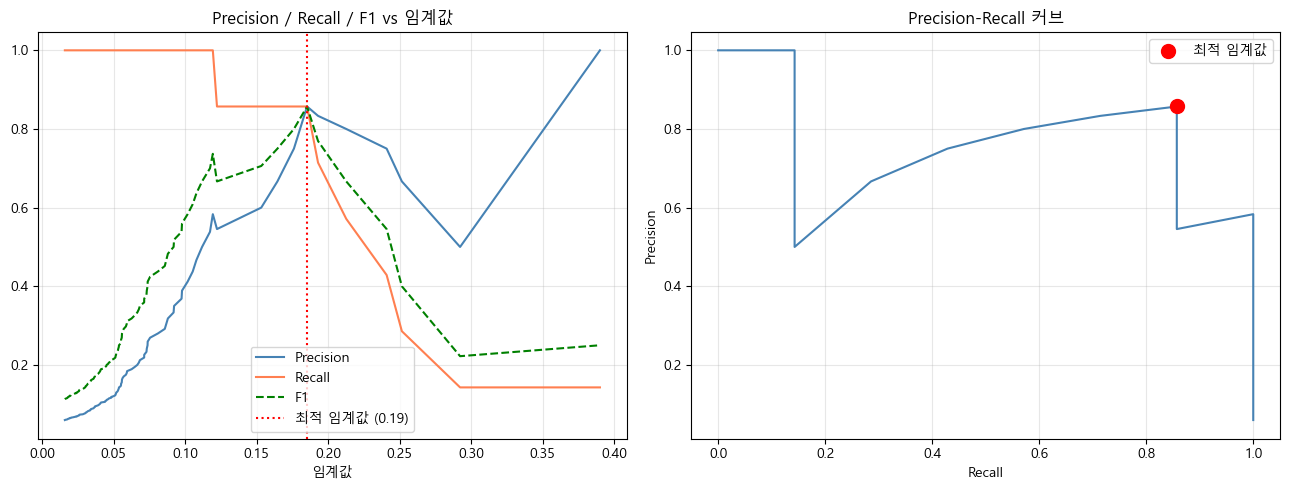

In [5]:
# ============================================================
# [개선 ⑥⑦] 캘리브레이션 + PR 커브 최적 임계값
# 원본: 확률 보정 없음, 임계값 0.5 고정
# 개선: sigmoid 캘리브레이션 + F1 최적 임계값 자동 탐색
# ============================================================
calibrated = CalibratedClassifierCV(
    Pipeline([
        ('scaler', StandardScaler()),
        ('logit',  LogisticRegression(C=best_C, max_iter=2000, class_weight='balanced', solver='lbfgs'))
    ]),
    method='sigmoid', cv=3
)
calibrated.fit(X, y)

facility_df['risk_prob']            = model_2nd.predict_proba(X)[:, 1]
facility_df['risk_prob_calibrated'] = calibrated.predict_proba(X)[:, 1]

# F1 최적 임계값
prec_arr, rec_arr, thr_arr = precision_recall_curve(y, facility_df['risk_prob_calibrated'])
f1_arr     = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
best_idx   = np.argmax(f1_arr)
best_thr   = thr_arr[best_idx]

print(f"최적 임계값: {best_thr:.3f}  |  Precision={prec_arr[best_idx]:.3f}  |  Recall={rec_arr[best_idx]:.3f}  |  F1={f1_arr[best_idx]:.3f}")
print(f"Average Precision Score: {average_precision_score(y, facility_df['risk_prob_calibrated']):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(thr_arr, prec_arr[:-1], label='Precision', color='steelblue')
axes[0].plot(thr_arr, rec_arr[:-1],  label='Recall',    color='coral')
axes[0].plot(thr_arr, f1_arr,        label='F1',        color='green', linestyle='--')
axes[0].axvline(x=best_thr, color='red', linestyle=':', label=f'최적 임계값 ({best_thr:.2f})')
axes[0].set_xlabel('임계값'); axes[0].set_title('Precision / Recall / F1 vs 임계값')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(rec_arr, prec_arr, color='steelblue')
axes[1].scatter(rec_arr[best_idx], prec_arr[best_idx], color='red', s=100, zorder=5, label='최적 임계값')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall 커브')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


=== 안전점수 분포 (로그 변환) ===
count    117.00
mean      64.31
std       21.27
min        0.00
25%       52.40
50%       65.24
75%       79.14
max      100.00
Name: safety_score, dtype: float64


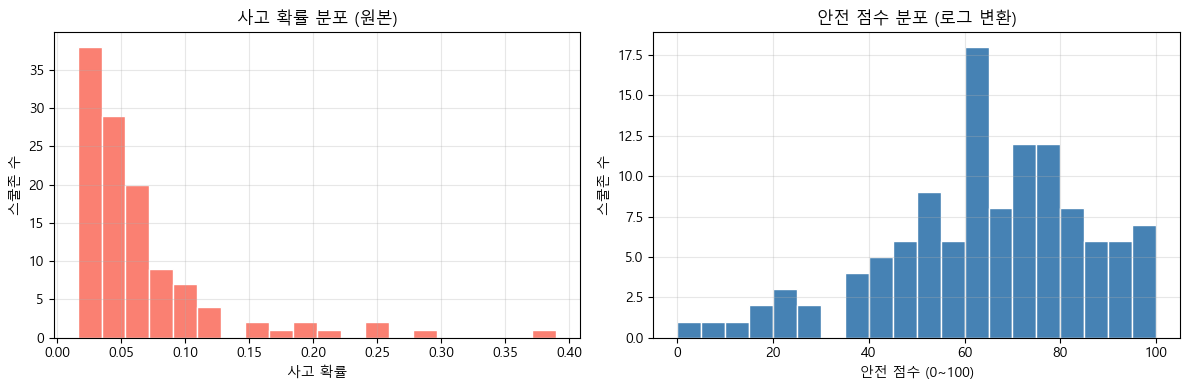

In [6]:
# ============================================================
# 안전점수 도출 — 로그 변환 스케일링 (방법 2)
# risk_prob_calibrated → log 변환 → min-max 정규화 → 0~100
# ============================================================

# -log10(p): 사고 확률 낮을수록 값이 커짐 (안전)
log_risk = -np.log10(facility_df['risk_prob_calibrated'].clip(lower=1e-6))

# min-max 정규화 → 0~100 (클수록 안전)
facility_df['safety_score'] = (
    (log_risk - log_risk.min()) / (log_risk.max() - log_risk.min()) * 100
)

print("=== 안전점수 분포 (로그 변환) ===")
print(facility_df['safety_score'].describe().round(2))

# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(facility_df['risk_prob_calibrated'], bins=20, color='salmon', edgecolor='white')
axes[0].set_title('사고 확률 분포 (원본)')
axes[0].set_xlabel('사고 확률'); axes[0].set_ylabel('스쿨존 수'); axes[0].grid(True, alpha=0.3)

axes[1].hist(facility_df['safety_score'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('안전 점수 분포 (로그 변환)')
axes[1].set_xlabel('안전 점수 (0~100)'); axes[1].set_ylabel('스쿨존 수'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# ============================================================
# 안전등급 — safety_score 기준 4분위 (A=안전, D=위험)
# ============================================================

# qcut: 데이터 분포에 따라 균등 분할 (각 등급 약 25%)
facility_df['safety_grade'] = pd.qcut(
    facility_df['safety_score'],
    q=4,
    labels=['D', 'C', 'B', 'A']   # 낮은 점수 → D, 높은 점수 → A
)

print("=== 안전등급 분포 ===")
for g in ['A', 'B', 'C', 'D']:
    cnt = (facility_df['safety_grade'] == g).sum()
    scores = facility_df[facility_df['safety_grade'] == g]['safety_score']
    print(f"  {g}등급: {cnt}개 ({cnt/len(facility_df)*100:.1f}%)  "
          f"점수 범위: {scores.min():.1f} ~ {scores.max():.1f}")


=== 안전등급 분포 ===
  A등급: 29개 (24.8%)  점수 범위: 79.7 ~ 100.0
  B등급: 29개 (24.8%)  점수 범위: 65.3 ~ 79.1
  C등급: 29개 (24.8%)  점수 범위: 53.1 ~ 65.2
  D등급: 30개 (25.6%)  점수 범위: 0.0 ~ 52.4


In [8]:
# ============================================================
# 최종 성능 평가
# ============================================================
y_pred = (facility_df['risk_prob_calibrated'] >= best_thr).astype(int)

print("=== Classification Report ===")
print(classification_report(y, y_pred, target_names=['비사고(0)', '사고(1)']))

cm = confusion_matrix(y, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix:  TN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"\n⚠️  FN(사고 있는데 없다고 예측) 최소화가 핵심 → 현재 Recall={tp/(fn+tp):.3f}")


=== Classification Report ===
              precision    recall  f1-score   support

      비사고(0)       0.99      0.99      0.99       110
       사고(1)       0.86      0.86      0.86         7

    accuracy                           0.98       117
   macro avg       0.92      0.92      0.92       117
weighted avg       0.98      0.98      0.98       117

Confusion Matrix:  TN=109 | FP=1 | FN=1 | TP=6

⚠️  FN(사고 있는데 없다고 예측) 최소화가 핵심 → 현재 Recall=0.857


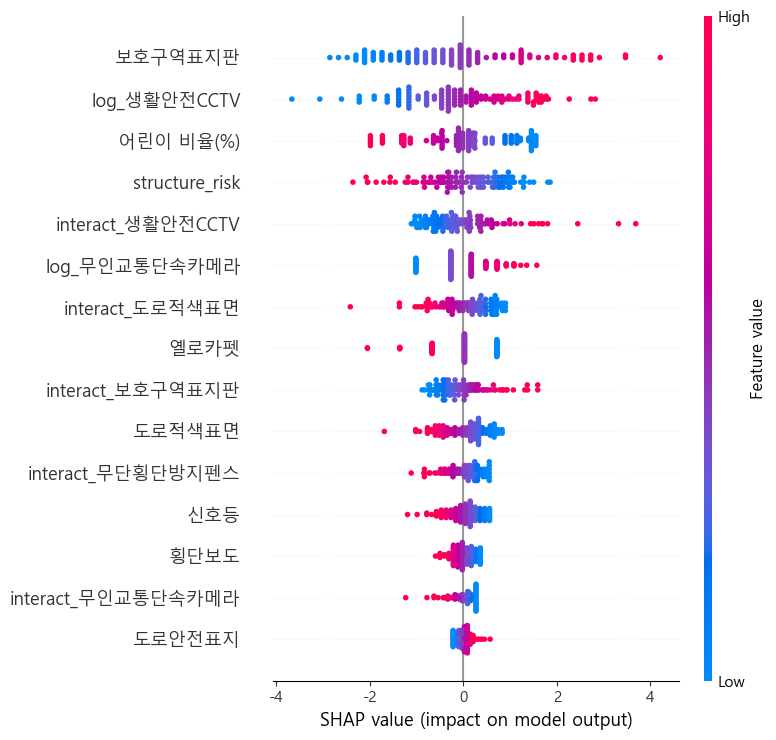

=== SHAP TOP 10 ===
          feature  shap_importance
          보호구역표지판         1.213014
     log_생활안전CCTV         0.965234
        어린이 비율(%)         0.750105
   structure_risk         0.719024
interact_생활안전CCTV         0.627958
    log_무인교통단속카메라         0.504317
  interact_도로적색표면         0.468052
             옐로카펫         0.419167
 interact_보호구역표지판         0.416331
           도로적색표면         0.411778


In [9]:
# ============================================================
# SHAP 변수 중요도
# ============================================================
inner_est     = calibrated.calibrated_classifiers_[0].estimator
X_scaled_shap = inner_est.named_steps['scaler'].transform(X)
logit_shap    = inner_est.named_steps['logit']

explainer   = shap.LinearExplainer(logit_shap, X_scaled_shap)
shap_values = explainer.shap_values(X_scaled_shap)

shap.summary_plot(shap_values, X, feature_names=features_2nd, max_display=15, show=True)

shap_df = pd.DataFrame({
    'feature': features_2nd,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance', ascending=False)

print("=== SHAP TOP 10 ===")
print(shap_df.head(10).to_string(index=False))


In [10]:
# ============================================================
# 최종 결과 저장
# ============================================================
result_df = facility_df[[c for c in [
    '시설물명','위도','경도','발생건수','accident_label',
    'structure_risk','risk_prob','risk_prob_calibrated',
    'risk_score','safety_score','safety_grade'
] if c in facility_df.columns]].copy()

result_df = result_df.sort_values('risk_prob_calibrated', ascending=False).reset_index(drop=True)

output_path = "./3_final_scoring_results_improved.csv"
result_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"저장 완료 ✅  →  {output_path}")
print()
print(result_df[['시설물명','발생건수','risk_prob_calibrated','safety_grade']].head(15).to_string(index=False))


저장 완료 ✅  →  ./3_final_scoring_results_improved.csv

     시설물명  발생건수  risk_prob_calibrated safety_grade
아이세상 어린이집     3              0.390156            D
 판교대장초등학교     0              0.292352            D
   금빛초등학교     3              0.251635            D
   성남어린이집     3              0.240988            D
  신흥성모유치원     3              0.212736            D
    성체유치원     3              0.193018            D
    은서유치원     3              0.185333            D
   성현어린이집     0              0.176144            D
  분당중앙유치원     0              0.164607            D
 신흥제2어린이집     0              0.153296            D
   대일초등학교     0              0.122336            D
 위례푸른초등학교     3              0.119424            D
   중부초등학교     0              0.117447            D
   즐거운유치원     0              0.111892            D
   금상초등학교     0              0.107942            D


In [11]:
import joblib

# 모델 저장
joblib.dump(calibrated, '2nd_model_calibrated.pkl')
joblib.dump(model_2nd,  '2nd_model_pipeline.pkl')

print("모델 저장 완료 ✅")
print("  - 2nd_model_calibrated.pkl  ← 확률 보정 모델 (risk_prob_calibrated 생성용)")
print("  - 2nd_model_pipeline.pkl    ← 원본 파이프라인 (risk_prob 생성용)")


모델 저장 완료 ✅
  - 2nd_model_calibrated.pkl  ← 확률 보정 모델 (risk_prob_calibrated 생성용)
  - 2nd_model_pipeline.pkl    ← 원본 파이프라인 (risk_prob 생성용)


In [12]:
## 모델 불러오는 코드
# import joblib

# calibrated = joblib.load('2nd_model_calibrated.pkl')
# model_2nd  = joblib.load('2nd_model_pipeline.pkl')

# # 새 데이터에 바로 적용
# new_prob = calibrated.predict_proba(X_new)[:, 1]
